# Klasterdamine

## Sisukord

* [Sarnaste objektide klastritesse rühmitamine k-keskmiste(*k-means*) meetodiga](#k_means_p)
* [Klastrite visualiseerimine üle kahe atribuudi korral](#n_attr)
* [Ülesanne 11.1](#11_1)
* [K-keskmiste meetodi teooria](#k_means_t)
* [Küünarnukimeetod](#kyynar)
* [Siluetimeetod](#siluett)
* [Hierarhiline klasterdamine](#hier)
* [DBSCAN meetod](#DBSCAN)
* [Ülesanne 11.2](#11_2)

Põhineb S.Raschka *Python Machine Learnig* raamatu 
[peatükil 11](https://github.com/rasbt/python-machine-learning-book/blob/master/code/ch11) ([*MIT litsents*](https://github.com/rasbt/python-machine-learning-book/blob/master/LICENSE.txt)).

<a id='k_means_p'></a>
## Sarnaste objektide klastritesse rühmitamine k-keskmiste(*k-means*) meetodiga *sklearn* teegis

Klasterdamine on kirjeldava andmeanalüüsi meetod, mille eesmärgiks pole klassi või arvväärtuse ennustamine, vaid andmete struktuuri kirjeldamine. Klasterdamise eesmärk on sarnaste ehk lähedaste objektide jaotamine gruppidesse ehk klastritesse. Tüüpiliselt põhineb sarnasus objektide kui n-mõõtmeliste punktide kaugusel teatud mõõdu järgi (Eukleidese kaugus jms). Kõigepealt vaatame klasterdamismeetodi praktilist kasutamist klassi [KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) näitel.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine, make_blobs, make_moons
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
# Genereerime juhusliku müraga kolme gruppi kuuluvad 2D andmed

X, y = make_blobs(n_samples=150,
                  n_features=2,
                  centers=3,
                  cluster_std=0.5,
                  shuffle=True,
                  random_state=0)
X

array([[ 2.60509732,  1.22529553],
       [ 0.5323772 ,  3.31338909],
       [ 0.802314  ,  4.38196181],
       [ 0.5285368 ,  4.49723858],
       [ 2.61858548,  0.35769791],
       [ 1.59141542,  4.90497725],
       [ 1.74265969,  5.03846671],
       [ 2.37533328,  0.08918564],
       [-2.12133364,  2.66447408],
       [ 1.72039618,  5.25173192],
       [ 3.1368855 ,  1.56592763],
       [-0.37494566,  2.38787435],
       [-1.84562253,  2.71924635],
       [ 0.72144399,  4.08475018],
       [ 0.16117091,  4.53517846],
       [-1.99912714,  2.71285741],
       [-1.47804153,  3.2093591 ],
       [ 1.8706766 ,  0.77797407],
       [-1.5933443 ,  2.76898682],
       [ 2.03562611,  0.31361691],
       [ 0.64003985,  4.12401075],
       [ 2.4411628 ,  1.30941574],
       [ 1.13280393,  3.87673946],
       [ 1.04829186,  5.03092408],
       [-1.26637157,  2.62998828],
       [ 2.31690585,  0.81189049],
       [ 2.36230721,  1.358767  ],
       [ 1.2091013 ,  3.53566548],
       [-2.54224625,

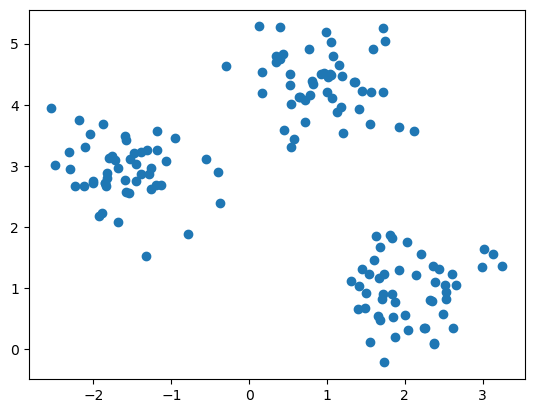

In [3]:
# %matplotlib inline
colormap = {0: "red", 1: "blue", 2: "yellow"}
            
plt.scatter(X[:, 0], X[:, 1])
plt.show()
#plt.grid()

In [4]:
# Meetod fit_predict väljastab klasterdamismeetodi korral klastrinumbrite vektori
# KMeans eeldab, et anname eeldatava klastrite arvu n_clusters ette.
km = KMeans(n_clusters=3, 
           init='random',
           n_init=10,  # Kui mitme erineva tsentroidide juhusliku algväärtustamisega proovida
           max_iter=300,
           tol=0.00001,
           random_state=0)
y_km = km.fit_predict(X)
y_km

c:\Users\Maive\miniconda3\envs\andmekaeve_suurandmetest\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([2, 1, 1, 1, 2, 1, 1, 2, 0, 1, 2, 0, 0, 1, 1, 0, 0, 2, 0, 2, 1, 2,
       1, 1, 0, 2, 2, 1, 0, 2, 0, 0, 0, 0, 1, 2, 2, 2, 1, 1, 0, 0, 1, 2,
       2, 2, 0, 1, 0, 1, 2, 1, 1, 2, 2, 0, 1, 2, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 2, 1, 1, 1, 2, 2, 1, 2, 1, 1, 0, 0, 1, 2, 2, 1, 1, 2, 2, 2, 0,
       0, 2, 2, 1, 2, 1, 2, 1, 0, 0, 2, 2, 2, 2, 0, 2, 2, 1, 0, 1, 1, 1,
       0, 1, 2, 0, 1, 0, 1, 1, 0, 0, 1, 2, 1, 1, 2, 2, 0, 2, 0, 0, 0, 0,
       2, 0, 0, 0, 1, 0, 2, 0, 1, 1, 2, 2, 0, 0, 0, 0, 2, 2])

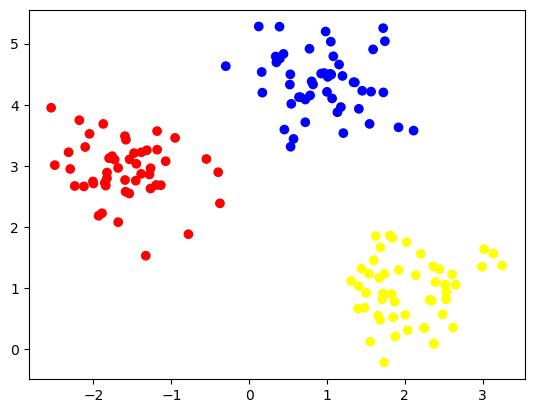

In [5]:
# Kuvame klastrid värviliselt
colormap = {0: "red", 1: "blue", 2: "yellow", 
            3: "green", 4: "cyan", 5: "orange",
            6: "purple", 7: "brown", 8: "magenta",
            -1: "black"}
plt.scatter(X[:, 0], X[:, 1], c=[colormap[c_id] for c_id in y_km])
#plt.grid()
plt.show()

In [6]:
# Vaatame klastrite keskpunkte
km.cluster_centers_

array([[-1.5947298 ,  2.92236966],
       [ 0.9329651 ,  4.35420712],
       [ 2.06521743,  0.96137409]])

<a id='n_attr'></a>
## Klastrite visualiseerimine üle kahe atribuudi korral

Vaatame loomaaia andmeid ja eemaldame atribuudi `type` (üritame ise loomi klastrite abil grupeerida). 

In [7]:
zoo_df = pd.read_csv("http://archive.ics.uci.edu/ml/machine-learning-databases/zoo/zoo.data", 
                     header=None, index_col=0,
                     names=["animal_name", "hair", "feathers", "eggs", "milk", "airborne", "aquatic", "predator", "toothed", "backbone", "breathes", "venomous", "fins", "legs", "tail", "domestic", "catsize", "type" ])
zoo_df.pop("type")
zoo_df

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize
animal_name,,,,,,,,,,,,,,,,
aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1
antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1
bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0
bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1
boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
wallaby,1,0,0,1,0,0,0,1,1,1,0,0,2,1,0,1
wasp,1,0,1,0,1,0,0,0,0,1,1,0,6,0,0,0
wolf,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1


Loome konveieri, mis normaliseerib andmed ja leiab klastrid.

In [8]:
norm_km = Pipeline(steps=[("nm", MinMaxScaler()), 
                          ('km', KMeans(n_clusters=3, n_init=10))])
y_zoo = norm_km.fit_predict(zoo_df)
y_zoo

c:\Users\Maive\miniconda3\envs\andmekaeve_suurandmetest\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([0, 0, 2, 0, 0, 0, 0, 2, 2, 0, 0, 1, 2, 2, 2, 2, 1, 0, 2, 0, 1, 1,
       0, 1, 1, 2, 2, 0, 0, 0, 1, 0, 0, 1, 2, 0, 0, 1, 2, 1, 1, 1, 1, 1,
       0, 0, 2, 0, 0, 0, 0, 1, 2, 2, 0, 0, 1, 1, 1, 1, 2, 2, 2, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 2, 0, 0, 2, 2, 1, 1, 2, 1, 2, 1, 0, 2, 2, 1,
       1, 2, 1, 2, 2, 0, 0, 1, 0, 1, 0, 1, 1])

Visualiseerime klastrid peakomponentanalüüsi kahe olulisema komponendi abil.  Peakomponentanalüüsi teostamine enne klasterdamist on samuti mõeldav, aga visualiseerimiseks kasutatava kahe peakomponendiga piirdumine võib olla liigne lihtsustus.

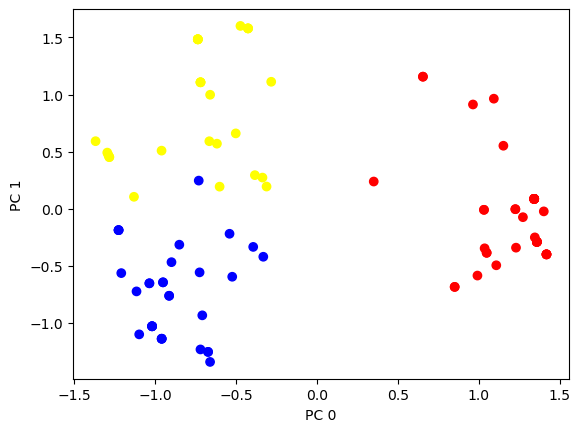

In [9]:
# Teisendame andmestiku kaheks peakomponendiks
norm_pca = Pipeline(steps=[("nm", MinMaxScaler()), 
                          ('pca', PCA(n_components=2))])
X_zoo_pca = norm_pca.fit_transform(zoo_df) 

# Kuvame loomade scatterploti peakomponentide ja 
# algsel andmestikul leitud klastritega.

plt.scatter(X_zoo_pca[:, 0], 
            X_zoo_pca[:, 1], 
            c=[colormap[y] for y in y_zoo])
plt.xlabel('PC 0')
plt.ylabel('PC 1')
plt.show()

Eelmistest ülesannetest tuttaval graafikul näeme, et klastrid jagavad loomad:
* imetajateks
* mitte-imetajateks
    * kes on veeloomad
    * kes pole veeloomad.

PCA asemel võib kasutada ka klastrite [seaborn.pairplot](https://seaborn.pydata.org/generated/seaborn.pairplot.html) visualiseerimist (parameeter `hue` määraks klastrid, mida siin tuleks käsitleda atribuudina), aga kuna loomaaia algsed atribuudid on valdavalt väärtustega (0,1), siis selles näites ei tuleks atribuudipaaride alamgraafikud kuigi huvitavad.

<a id='11_1'></a>
##  Ülesanne 11.1

Laadida veinide andmestik, nagu näidatud allpool. Standardiseerida see klassi [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) abil.

* Jaotada [KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) klassi abil andmed kolmeks klastriks.
* Kuvada need klastrid hajuvusgraafikul kahe [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)`(n_components=2)` peakomponendi  abil.
* Võrrelge leitud klastreid tegelike klassidega `yw`. Kuivõrd need kattuvad?

In [10]:
wine_data = load_wine()
wine_data

{'data': array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
         1.065e+03],
        [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
         1.050e+03],
        [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
         1.185e+03],
        ...,
        [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
         8.350e+02],
        [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
         8.400e+02],
        [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
         5.600e+02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

In [35]:
Xw = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
yw = wine_data.target
Xw.head()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


c:\Users\Maive\miniconda3\envs\andmekaeve_suurandmetest\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


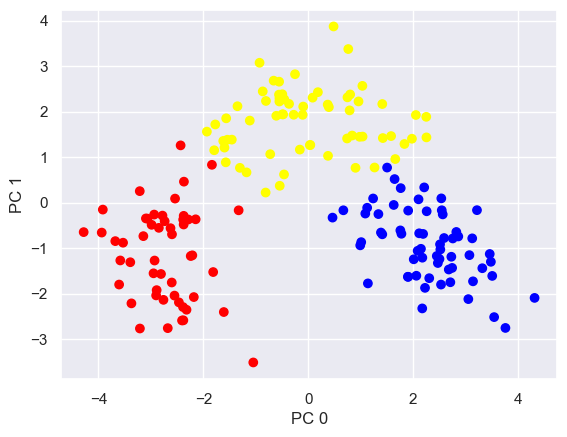

In [36]:
# Standardiseerin andmestiku 
# Jaotan andmed KMeans abil kolmeks klastriks
sc_kmeans = Pipeline([('sc', StandardScaler()), 
                      ('km', KMeans(n_clusters=3, n_init=10))])

y_km_w = sc_kmeans.fit_predict(Xw) 

# km_w = sc_kmeans.fit_transform(Xw)

# Leian kaks peakomponenti
pca = Pipeline([('sc', StandardScaler()), 
                      ('pca', PCA(n_components=2))])
Xw_pca = pca.fit_transform(Xw) 


# Kuvame veinide scatterploti 2 peakomponendi ja algsel andmestikul leitud klastritega.

plt.scatter(Xw_pca[:, 0], 
            Xw_pca[:, 1], 
            c=[colormap[y] for y in y_km_w])
plt.xlabel('PC 0')
plt.ylabel('PC 1')
plt.show()

In [37]:
# Võrrelge leitud klastreid tegelike klassidega `yw`. Kuivõrd need kattuvad?

print(f'Need kattuvad {(sum(yw == y_km_w))/len(yw)} ulatuses')
yw == y_km_w


Need kattuvad 0.016853932584269662 ulatuses


array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False,  True, False, False, False, False,
       False, False,

<a id='k_means_t'></a>
## K-keskmiste meetodi teooria

K-keskmiste klasterdamine põhineb $m$-mõõtmelise andmestiku kahe punkti (objekti) $x$, $y$  vahelise Eukleidese kauguse ruudul:

$$ d(\textbf{x}, \textbf{y})^2 = \sum_{j=1}^m (x_j - y_j)^2 $$

In [14]:
# import numpy as np
def d_squared(x, y):
    return sum((x-y)**2)

x = np.array([1, 2, 3])
y = np.array([2, 1, -1])
print(d_squared(x, y))
print(d_squared(y, x))
print(d_squared(x, x))

18
18
0


K-keskmiste klasterdamine minimeerib $k$ klastri punktide $\pmb{x}^{(i)}$ ja  klastri keskpunktide $\pmb{\mu}^{(j)}$ vaheliste kauguste (vigade)  ruutude $d(\pmb{x}, \pmb{\mu})^2$ summat (*sum of squared errors*):
$$ SSE = \sum_{i=1}^n \sum_{j=1}^k w^{(i, j)} d(\pmb{x}^{(i)}, \pmb{\mu}^{(j)})^2 $$
Kaal $w^{(i, j)}$ on 1 kui objekt ${x}^{(i)}$ kuulub klastrisse $j$, muidu on see kaal 0. Klastrite arv $k$ on etteantud.

<a id='kyynar'></a>
## Küünarnuki (*elbow*) meetod optimaalse klastrite arvu hindamiseks

Optimaalse klastrite arvu leidmiseks saab kasutada $SSE$ mõõtu (kui on tegemist Eukleidese kaugusega). $SSE$ väheneb koos klastrite arvu kasvamisega, alguses tavaliselt kiiresti, hiljem aeglasemalt. Üldiselt soovime me kombineerida väikese klastrite arvu väikese $SSE$ mõõduga. Küünarnuki meetod tähendab $SSE$, klastrite arv graafikul nullpunktile lähima kombinatsiooni (küünarnuki) leidmist. Scikit-learn teegis vastab $SSE$ mõõdule  `KMeans` objekti atribuut `inertia_`.

c:\Users\Maive\miniconda3\envs\andmekaeve_suurandmetest\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


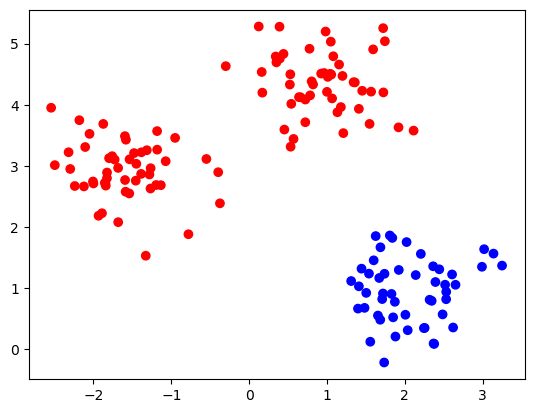

c:\Users\Maive\miniconda3\envs\andmekaeve_suurandmetest\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


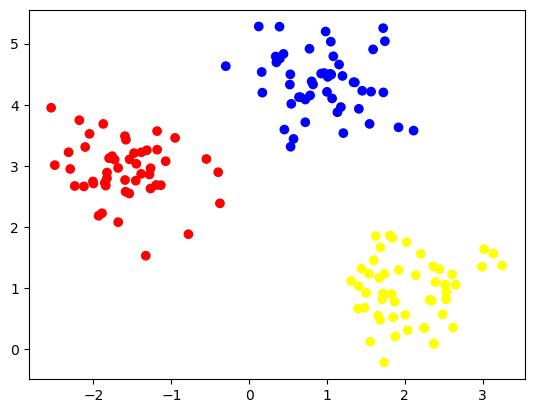

c:\Users\Maive\miniconda3\envs\andmekaeve_suurandmetest\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


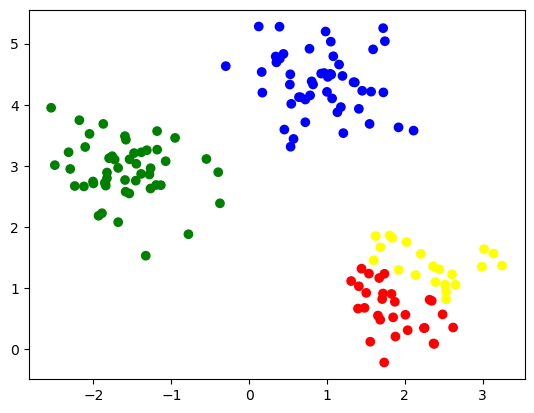

c:\Users\Maive\miniconda3\envs\andmekaeve_suurandmetest\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


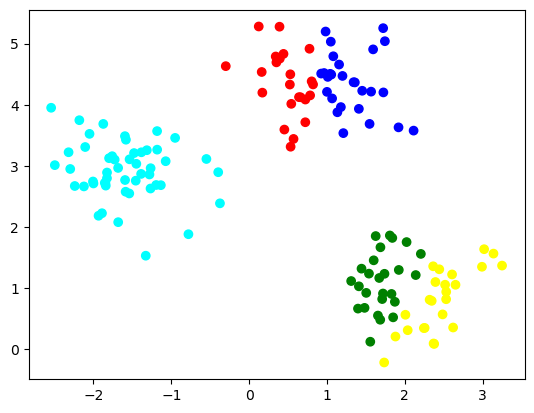

c:\Users\Maive\miniconda3\envs\andmekaeve_suurandmetest\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


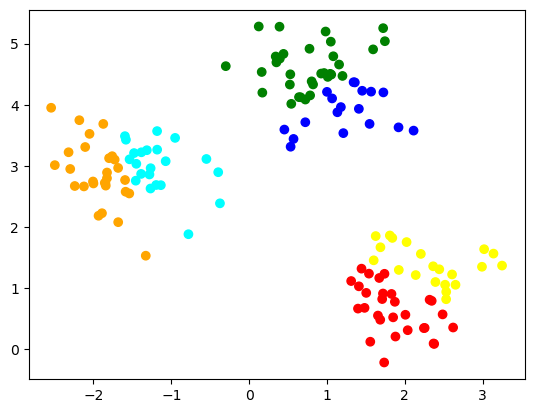

c:\Users\Maive\miniconda3\envs\andmekaeve_suurandmetest\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


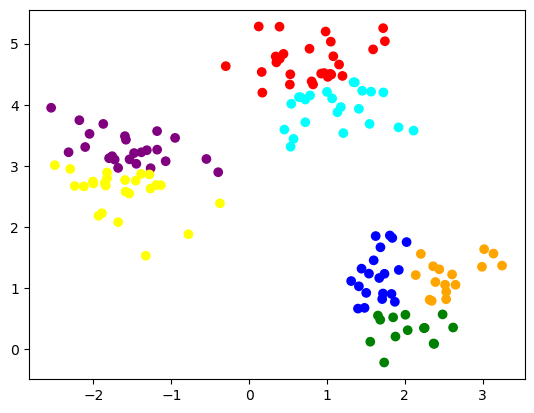

c:\Users\Maive\miniconda3\envs\andmekaeve_suurandmetest\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


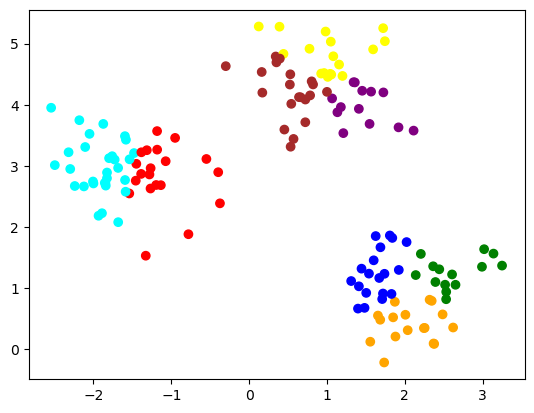

c:\Users\Maive\miniconda3\envs\andmekaeve_suurandmetest\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


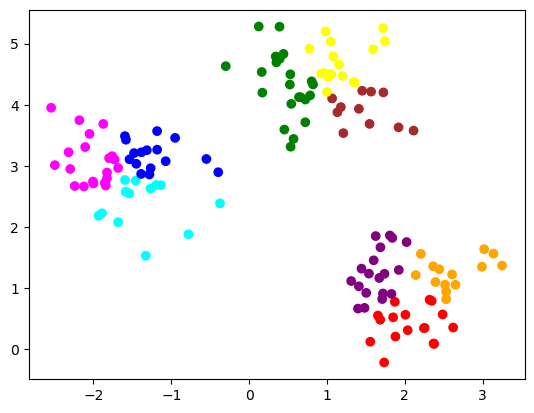

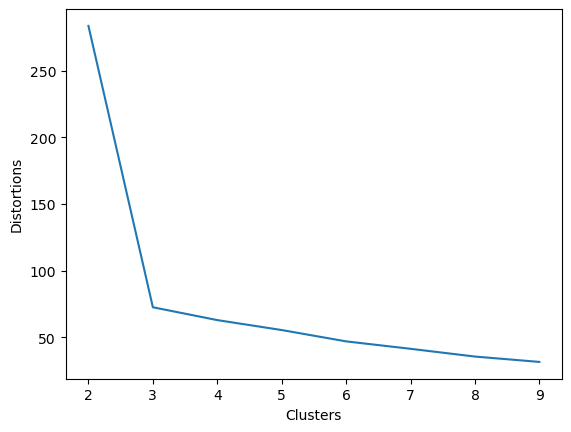

In [15]:
distortions = []
for i in range(2, 10):
    km.set_params(n_clusters=i)
    y_km_i = km.fit_predict(X)
    plt.scatter(X[:, 0], X[:, 1], c=[colormap[c_id] for c_id in y_km_i])
    #plt.grid()
    plt.show()
    distortions.append(km.inertia_)
    
# Distortion ehk SSE, graafikul näha hästi nn küünarnukki, kus optimaalseim klastrite arv (kui müra on palju, nt kui andmete varieeruvus on suur, siis graafikul küünarnukk hästi ei eristu või on nö trepp-graafik)     
plt.plot(range(2, 10), distortions) 
plt.xlabel("Clusters")
plt.ylabel("Distortions")
plt.show()

<a id='siluett'></a>
## Siluetidiagrammid

Alternatiivne ja detailsem klasterdamise kvaliteedi hindamise meetod on siluetianalüüs, mis võimaldab hinnata, kuvõrd tihedalt klastrid objekte grupeerivad. Igale objektile $i$ leitakse siluetikoefitsent $s^{(i)}$:

$$ s^{(i)} = \frac{b^{(i)} - a^{(i)}}{max(b^{(i)}, a^{(i)})} $$

, kus $a^{(i)}$ on objekti $i$ keskmine kaugus sama klastri objektidest ja  $b^{(i)}$ on objekti $i$ keskmine kaugus järgmise lähima klastri objektidest. Siluetikoefitsent on vahemikus -1 ja 1, ideaaljuhul $b^{(i)} >> a^{(i)}$ on see 1, juhul kui $b^{(i)} = a^{(i)}$ on siluetikoefitsent 0.

Siluetidiagrammil on klastrid näidatud erinevate värvidega ja objektid, millele vastavad objekti siluetikoefitsenti horisontaaljooned, on klastri sees sorditud siluetikoefitsendi järgi. Keskmist siluetikoefitsenti kujutab punane vertikaalpunktiir. Olulised asjad, mida sellel diagrammil kontrollida on keskmine siluetikoefitsent, klastrite suurus (võiksid olla enam-vähem võrdsed), eriti madala siluetikoefitsendiga objektide (anomaaliate) arv ja jaotus klastrite vahel.


In [16]:
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm

def draw_silhouette_plots(X, range_n_clusters = range(2, 10)):

# See kood on võetud suuresti 
# https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html#sphx-glr-auto-examples-cluster-plot-kmeans-silhouette-analysis-py

    for n_clusters in range_n_clusters:
        # Create a subplot with 1 row and 2 columns
        fig, (ax1, ax2) = plt.subplots(1, 2)
        fig.set_size_inches(18, 7)

        # The 1st subplot is the silhouette plot
        # The silhouette coefficient can range from -1, 1 but in this example all
        # lie within [-0.1, 1]
        ax1.set_xlim([-0.1, 1])
        # The (n_clusters+1)*10 is for inserting blank space between silhouette
        # plots of individual clusters, to demarcate them clearly.
        ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

        # Initialize the clusterer with n_clusters value and a random generator
        # seed of 10 for reproducibility.
        clusterer = KMeans(n_clusters=n_clusters, n_init=10, random_state=10)
        cluster_labels = clusterer.fit_predict(X)

        # The silhouette_score gives the average value for all the samples.
        # This gives a perspective into the density and separation of the formed
        # clusters
        silhouette_avg = silhouette_score(X, cluster_labels)
        print("For n_clusters =", n_clusters,
              "The average silhouette_score is :", silhouette_avg)

        # Compute the silhouette scores for each sample
        sample_silhouette_values = silhouette_samples(X, cluster_labels)

        y_lower = 10
        for i in range(n_clusters):
            # Aggregate the silhouette scores for samples belonging to
            # cluster i, and sort them
            ith_cluster_silhouette_values = \
                sample_silhouette_values[cluster_labels == i]

            ith_cluster_silhouette_values.sort()

            size_cluster_i = ith_cluster_silhouette_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / n_clusters)
            ax1.fill_betweenx(np.arange(y_lower, y_upper),
                              0, ith_cluster_silhouette_values,
                              facecolor=color, edgecolor=color, alpha=0.7)

            # Label the silhouette plots with their cluster numbers at the middle
            ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

            # Compute the new y_lower for next plot
            y_lower = y_upper + 10  # 10 for the 0 samples

        ax1.set_title("The silhouette plot for the various clusters.")
        ax1.set_xlabel("The silhouette coefficient values")
        ax1.set_ylabel("Cluster label")

        # The vertical line for average silhouette score of all the values
        ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

        ax1.set_yticks([])  # Clear the yaxis labels / ticks
        ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

        # 2nd Plot showing the actual clusters formed
        colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
        ax2.scatter(X[:, 0], X[:, 1], marker='.', s=30, lw=0, alpha=0.7,
                    c=colors, edgecolor='k')

        # Labeling the clusters
        centers = clusterer.cluster_centers_
        # Draw white circles at cluster centers
        ax2.scatter(centers[:, 0], centers[:, 1], marker='o', 
                    c="white", alpha=1, s=200, edgecolor='k')

        for i, c in enumerate(centers):
            ax2.scatter(c[0], c[1], marker='$%d$' % i, alpha=1,
                        s=50, edgecolor='k')

        ax2.set_title("The visualization of the clustered data.")
        ax2.set_xlabel("Feature space for the 1st feature")
        ax2.set_ylabel("Feature space for the 2nd feature")

        plt.suptitle(("Silhouette analysis for KMeans clustering on sample data "
                      "with n_clusters = %d" % n_clusters),
                     fontsize=14, fontweight='bold')

    plt.show()

c:\Users\Maive\miniconda3\envs\andmekaeve_suurandmetest\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


For n_clusters = 2 The average silhouette_score is : 0.5848706144251782


c:\Users\Maive\miniconda3\envs\andmekaeve_suurandmetest\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Maive\miniconda3\envs\andmekaeve_suurandmetest\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


For n_clusters = 3 The average silhouette_score is : 0.7143417887288687
For n_clusters = 4 The average silhouette_score is : 0.5768508858868746


c:\Users\Maive\miniconda3\envs\andmekaeve_suurandmetest\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Maive\miniconda3\envs\andmekaeve_suurandmetest\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


...

For n_clusters = 7 The average silhouette_score is : 0.32514305768930285


c:\Users\Maive\miniconda3\envs\andmekaeve_suurandmetest\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


For n_clusters = 8 The average silhouette_score is : 0.3302732139543187


c:\Users\Maive\miniconda3\envs\andmekaeve_suurandmetest\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


For n_clusters = 9 The average silhouette_score is : 0.3377591263539952


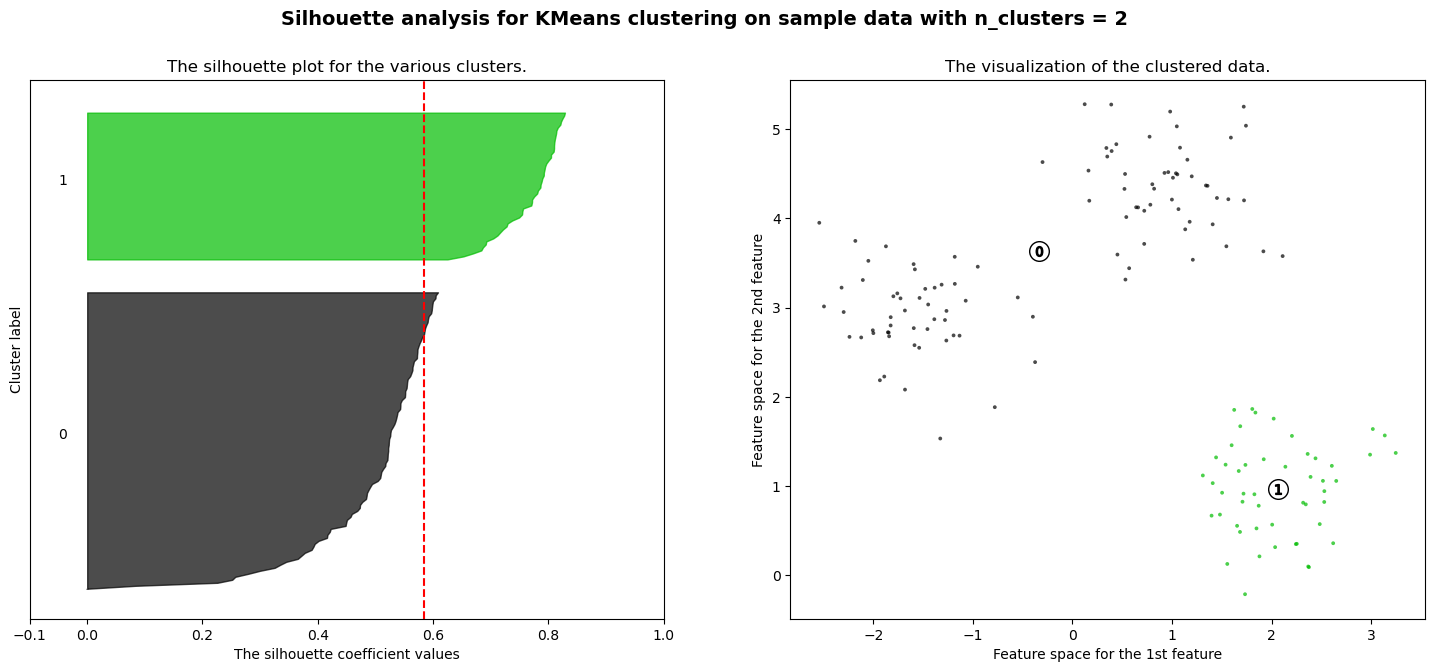

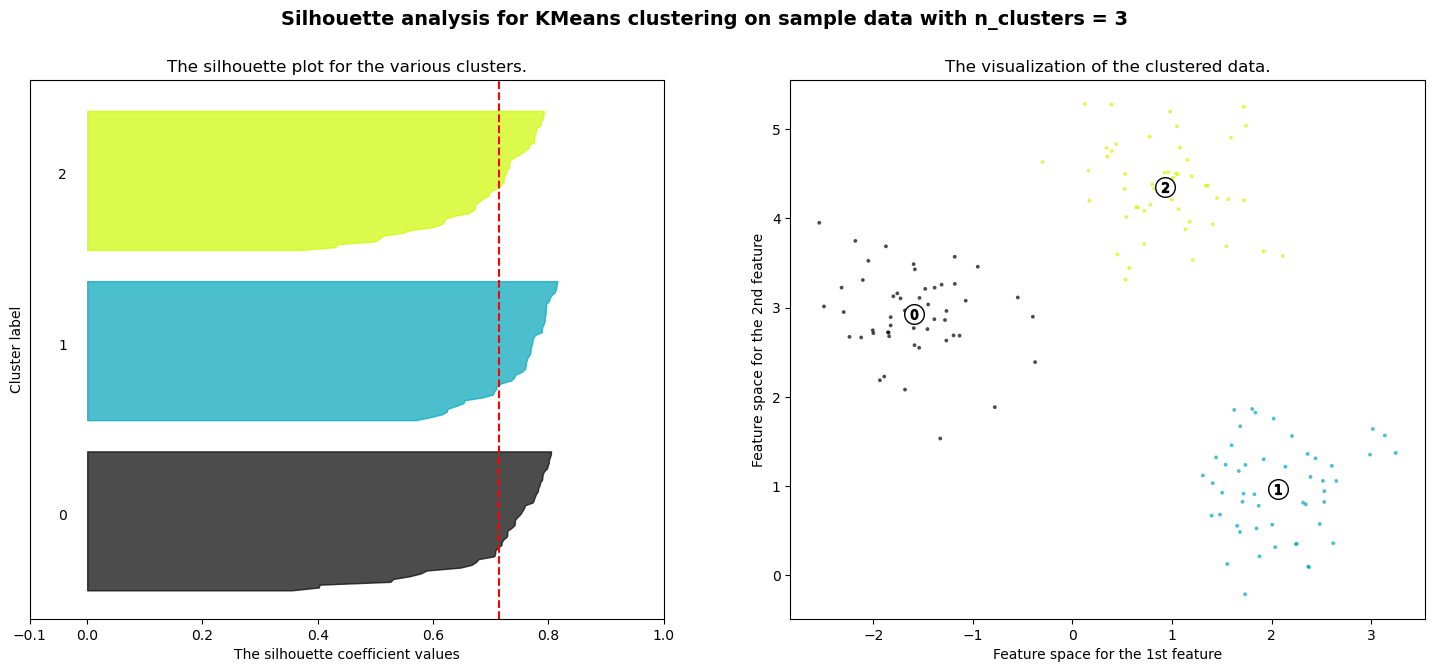

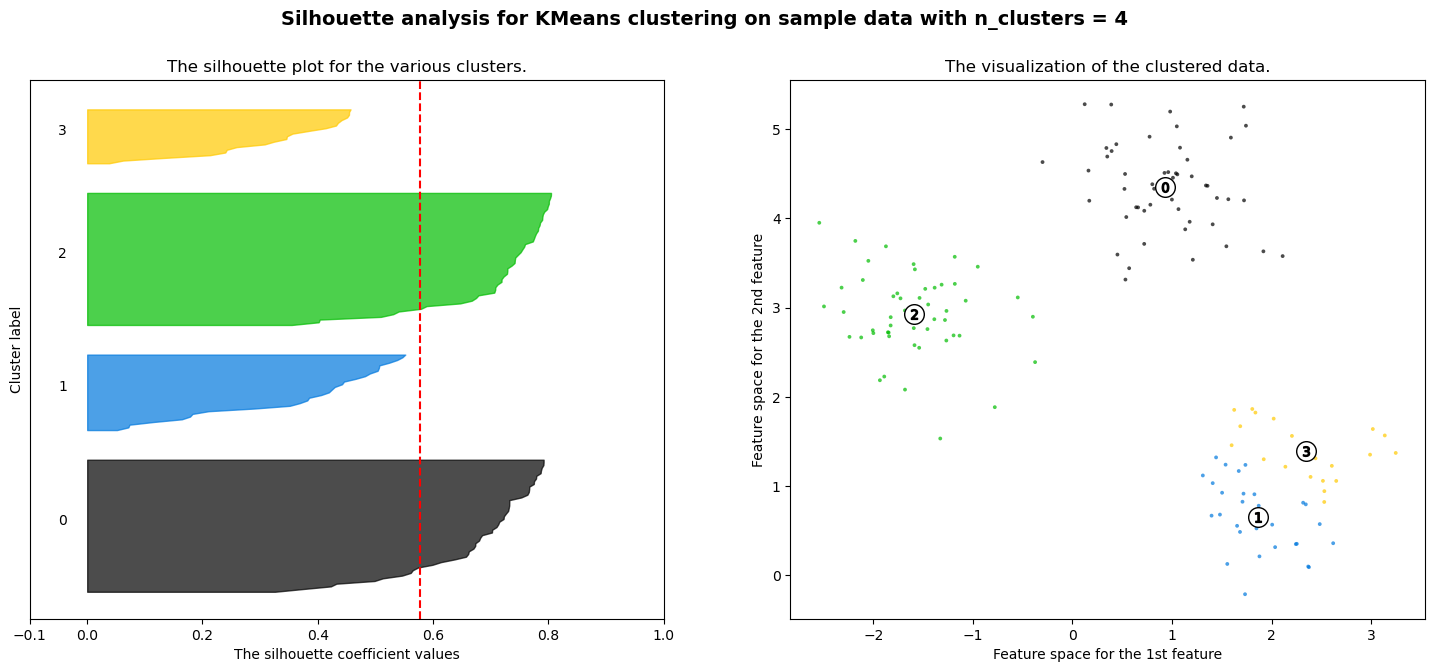

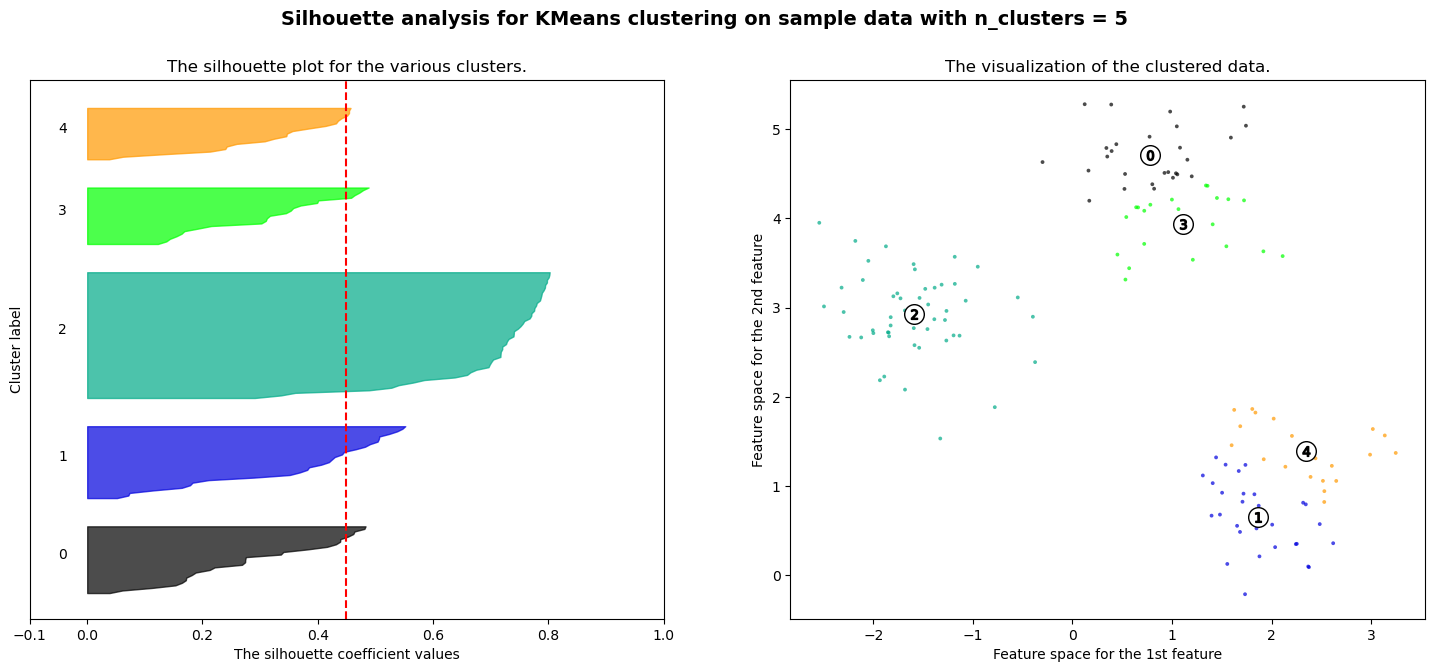

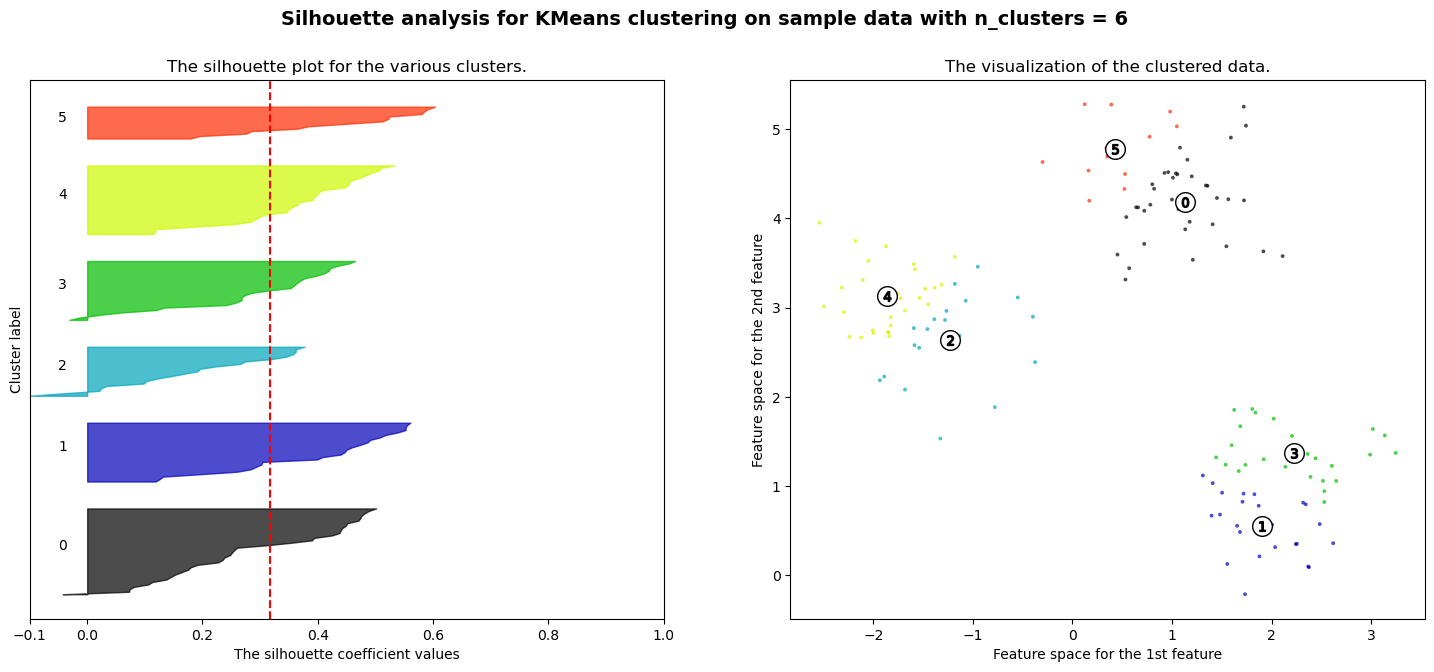

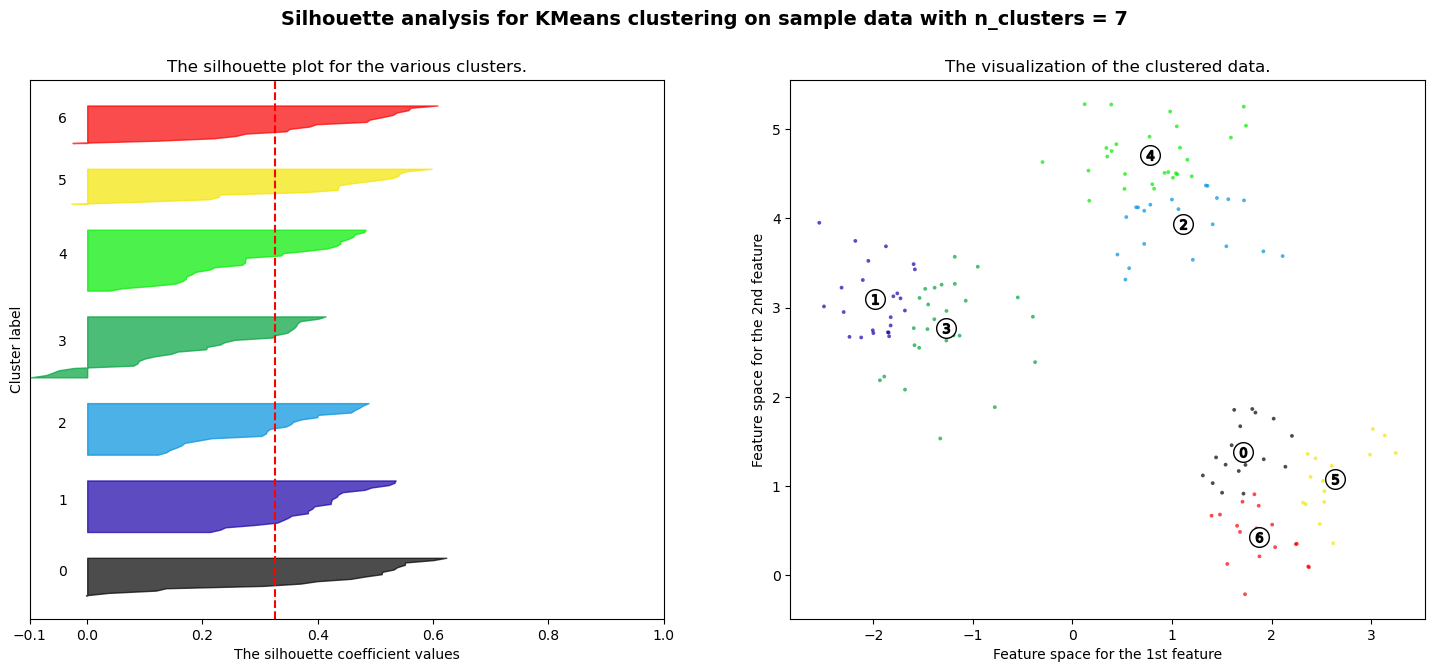

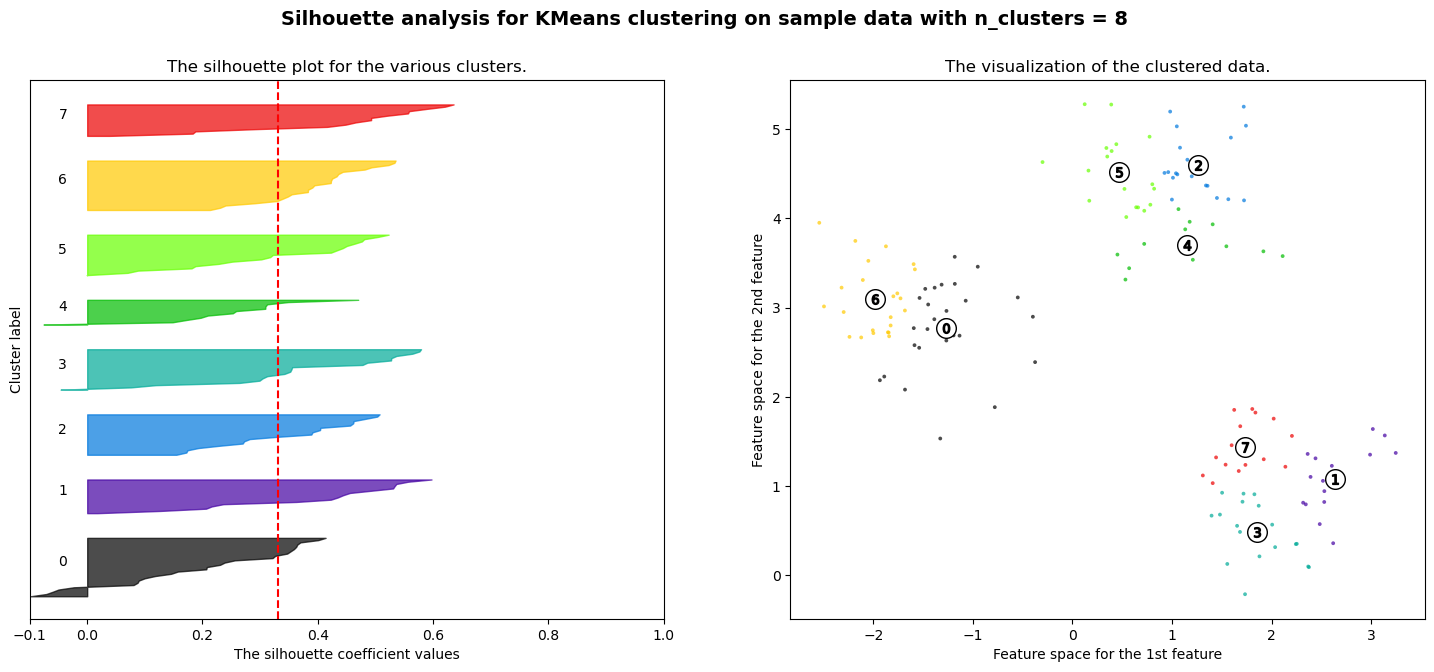

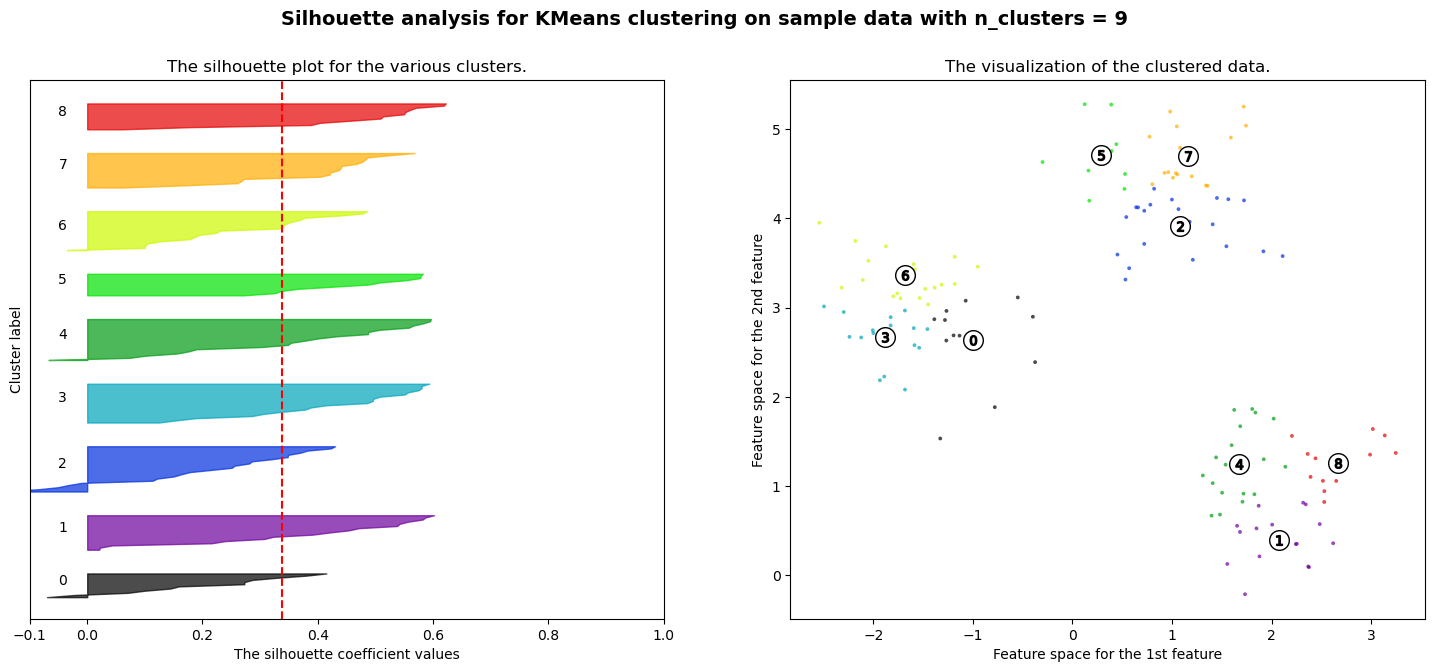

In [17]:
draw_silhouette_plots(X)

<a id='hier'></a>
## Hierarhiline klasterdamine

Hierarhiline klasterdamine organiseerib klastrid ülem-ja alamklastrite hierarhiaks. Siin ei ole vaja klastrite arvu ette anda. Vaatame näitena veinide atribuutide korrelatsioonimaatriksi korrastamist
[seaborn clustermap() funktsiooni](https://seaborn.pydata.org/generated/seaborn.clustermap.html) abil. Vt ka näiteks [AgglomerativeClustering](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html#sklearn.cluster.AgglomerativeClustering) klass.

In [18]:
cols = wine_data.feature_names
W_cm = pd.DataFrame(np.corrcoef(Xw.T), 
                    columns=cols, 
                    index=cols)
W_cm

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
alcohol,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720
malic_acid,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011
ash,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626
alcalinity_of_ash,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597
magnesium,0.270798,-0.054575,0.286587,-0.083333,1.000000,0.214401,0.195784,-0.256294,0.236441,0.199950,0.055398,0.066004,0.393351
total_phenols,0.289101,-0.335167,0.128980,-0.321113,0.214401,1.000000,0.864564,-0.449935,0.612413,-0.055136,0.433681,0.699949,0.498115
flavanoids,0.236815,-0.411007,0.115077,-0.351370,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.172379,0.543479,0.787194,0.494193
nonflavanoid_phenols,-0.155929,0.292977,0.186230,0.361922,-0.256294,-0.449935,-0.537900,1.000000,-0.365845,0.139057,-0.262640,-0.503270,-0.311385
proanthocyanins,0.136698,-0.220746,0.009652,-0.197327,0.236441,0.612413,0.652692,-0.365845,1.000000,-0.025250,0.295544,0.519067,0.330417
color_intensity,0.546364,0.248985,0.258887,0.018732,0.199950,-0.055136,-0.172379,0.139057,-0.025250,1.000000,-0.521813,-0.428815,0.316100


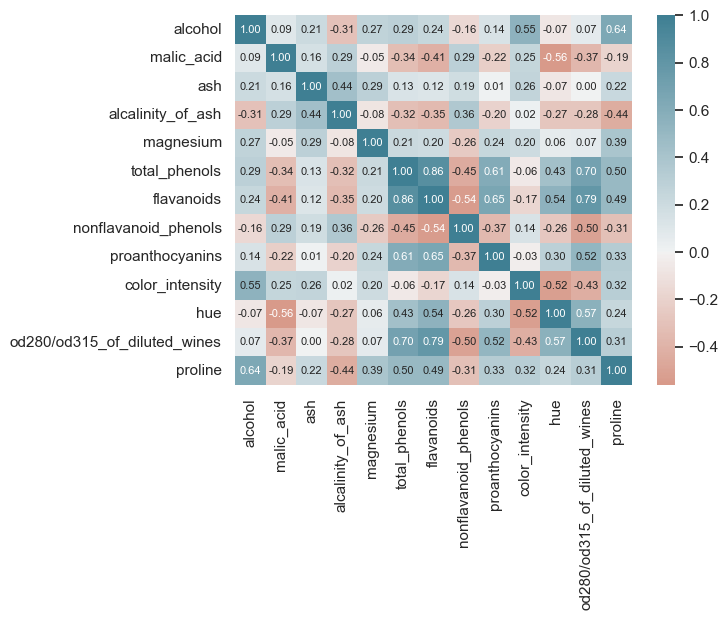

In [19]:
import seaborn as sns

cmap = sns.diverging_palette(20, 220, as_cmap=True)
sns.set(font_scale=1.0)
hm = sns.heatmap(W_cm, cbar=True, annot=True, fmt='.2f', cmap=cmap, center=0.0,
                 annot_kws={'size': 8}, yticklabels=cols, xticklabels=cols)

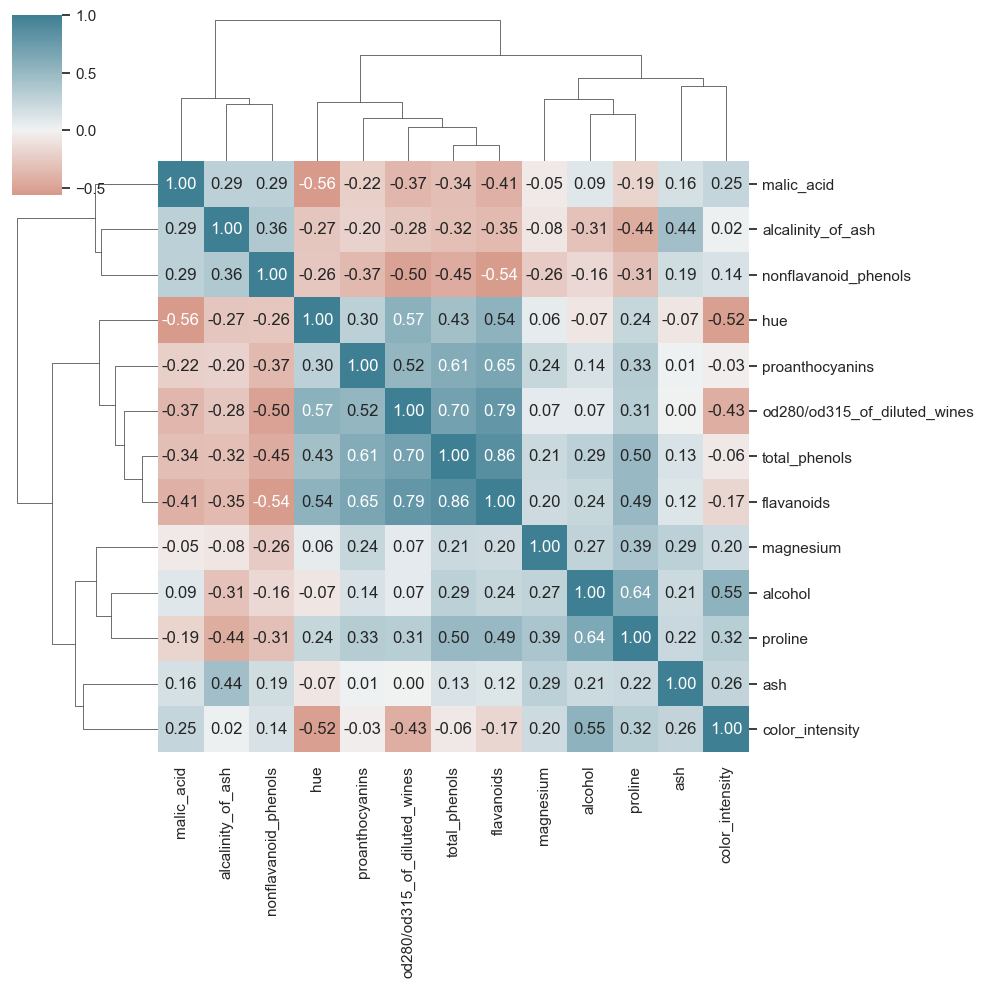

In [20]:
g = sns.clustermap(W_cm, annot=True, fmt='.2f', cmap=cmap, center=0.0)

Leiame hierarhilised klastrid loomaaiale.

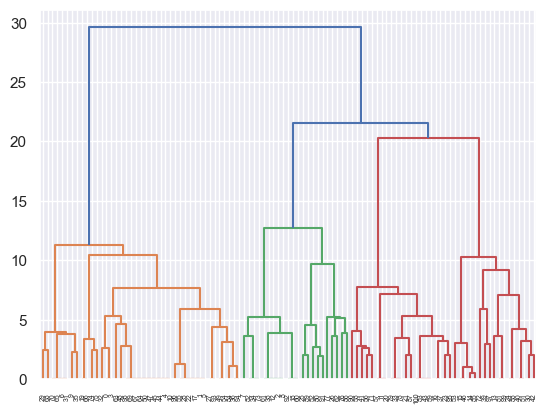

In [21]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram

zoo_df_std = pd.DataFrame(StandardScaler().fit_transform(zoo_df), index=zoo_df.index, columns=zoo_df.columns)

model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)

model.fit(zoo_df_std)


def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack([model.children_, model.distances_,
                                      counts]).astype(float)
    
    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)
    
plot_dendrogram(model)

Klasterdame loomaaia andmed (read ja veerud) hierarhiliselt Seaborn teegi abil. Pilt on kõikide siltide kuvamiseks suur ja vajab kerimist.

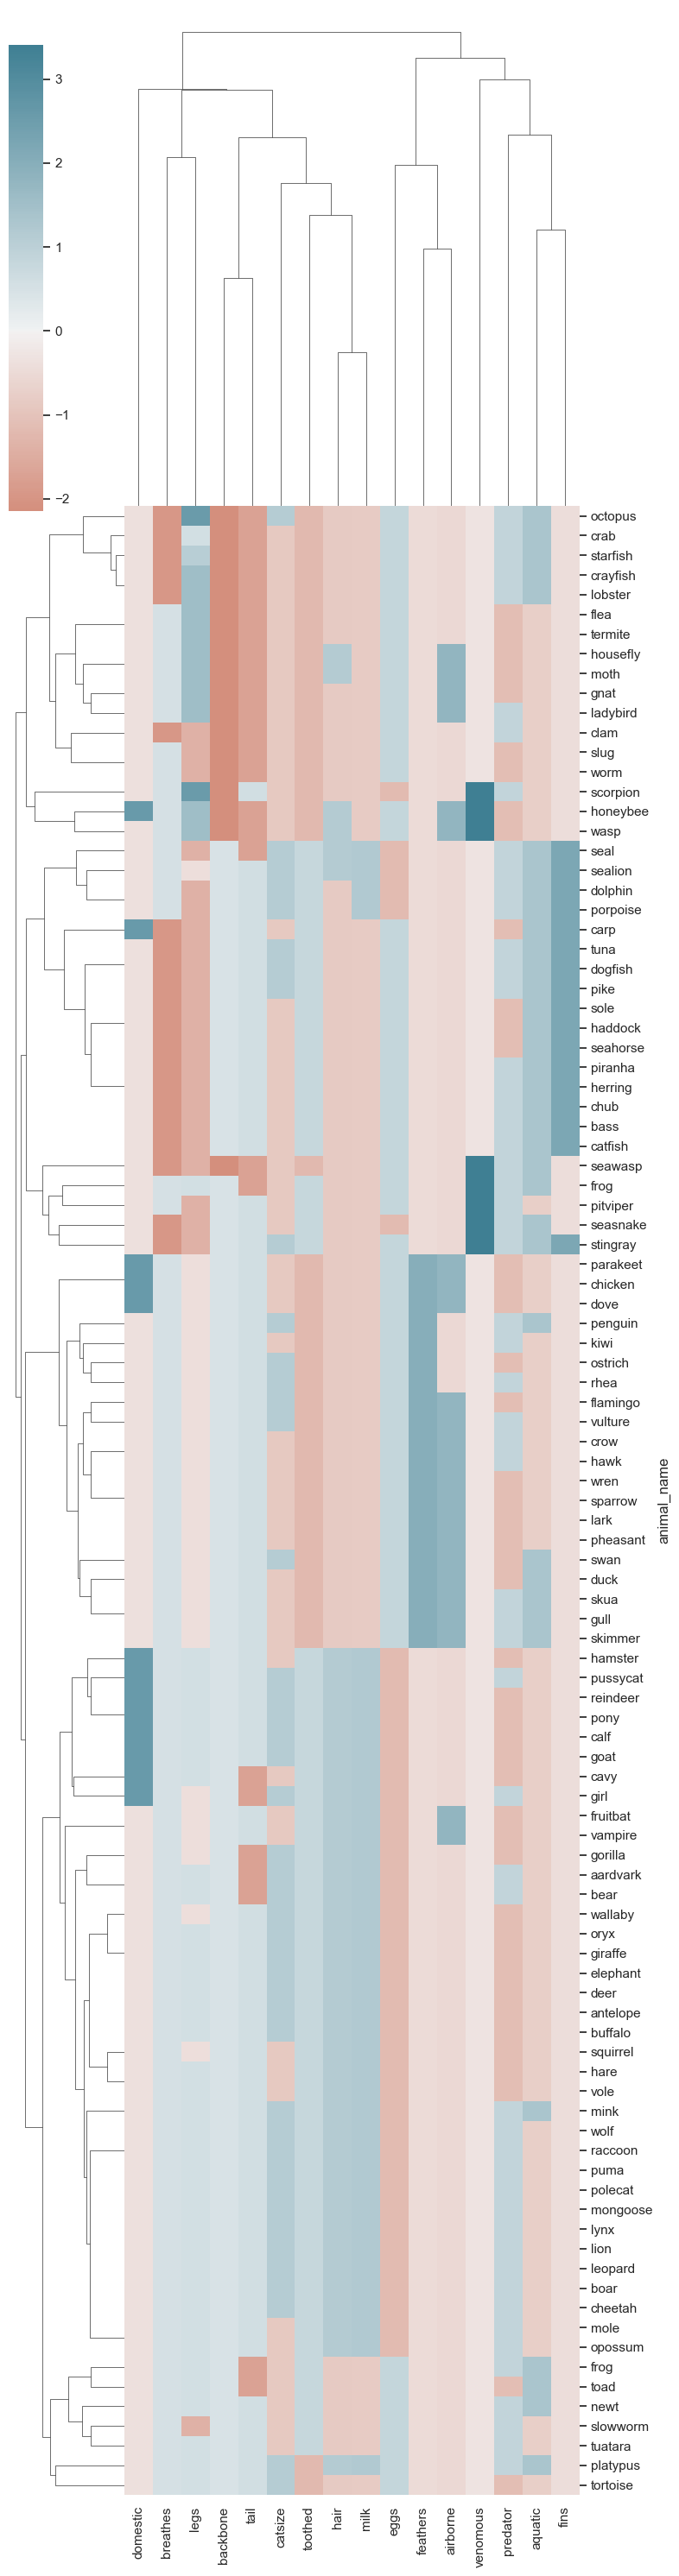

In [22]:
z = sns.clustermap(zoo_df_std, 
                   annot=False, 
                   cmap=cmap, 
                   center=0.0, 
                   figsize=(8, 30))

<a id='dbscan'></a>
## DBSCAN

K-keskmiste meetod sobib hästi ovaalisarnaste klastrite tuvastamiseks. Samas võivad meie andmepunktid moodustada keerukamaid kujundeid, kus lihtne kaugus klastri keskpunktist ei ole enam parim mõõt ja tasub kaaluda alternatiivseid meetodeid, nagu
[DBSCAN](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html) (*Density-Based Spatial Clustering of Applications with Noise*). 

Vaatame näidet, kus k-keskmiste meetod hätta jääb:

In [23]:
Xm, ym = make_moons(n_samples=150, noise=0.05, random_state=0)

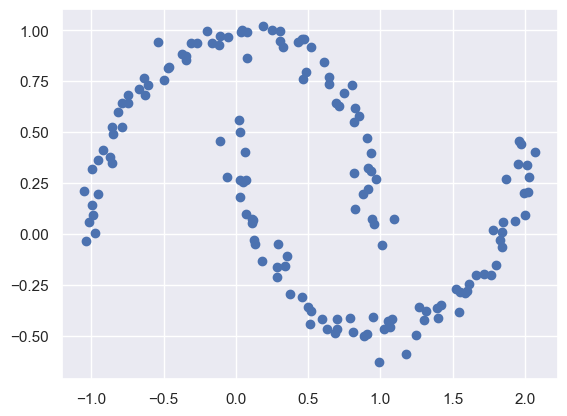

In [24]:
plt.scatter(Xm[:, 0], Xm[:, 1])
plt.show()

In [25]:
Xm[:5]

array([[ 1.05586049, -0.42505006],
       [-0.85916427,  0.5271783 ],
       [ 0.18510453,  1.02063553],
       [ 0.80875656, -0.47961843],
       [ 0.97096095,  0.27155877]])

c:\Users\Maive\miniconda3\envs\andmekaeve_suurandmetest\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


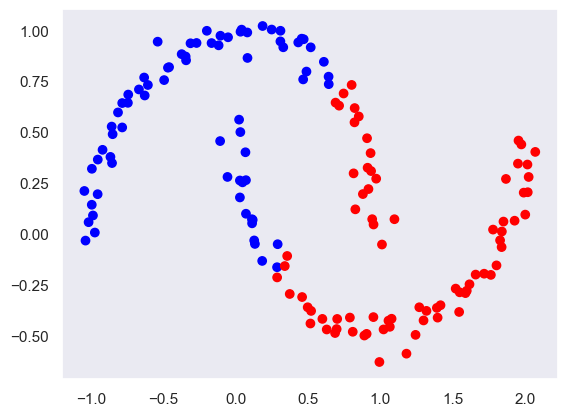

In [26]:
km.set_params(n_clusters=2)
ym_km = km.fit_predict(Xm)
plt.scatter(Xm[:, 0], Xm[:, 1], c=[colormap[c_id] for c_id in ym_km])
plt.grid()
plt.show()

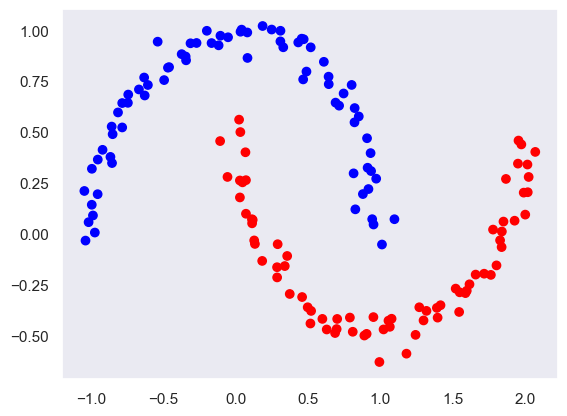

In [27]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.2, min_samples=5, metric='euclidean') # DBSCANis domineerib see, kes on kõige lähemad naabrid - ja need märgitakse ühte klastrisse
ym_db = db.fit_predict(Xm)
plt.scatter(Xm[:, 0], Xm[:, 1], c=[colormap[c_id] for c_id in ym_db])
plt.grid()
plt.show()

DBSCAN algoritm vajab kahte parameetrit:
* maksimaalne kaugus $\epsilon$ (sklearn eps) punktide naabriks lugemiseks
* minimaalne naaberpunktide arv $MinPoints$ tuumpunktil

Vastavalt nendele parameetritele jagatakse andmepunktid kolmeks:
* **tuumpunktid**, mille raadiuses $\epsilon$ on $MinPoints$ või rohkem punkti
* **piiripunktid**, mis on vähemalt ühe tuumpunkti  raadiuses $\epsilon$
* ülejäänud punktid on **mürapunktid**

Selle punktide liigituse järgi moodustavad klastri tuumpunktid või tuumpunktide grupid, mis on seotud kaugusest $\epsilon$ lühemate ühendustega (st kõigi grupi elementide vahel ei pea kaugus olema lühem kui $\epsilon$, aga neid peab siduma selliste väikeste kaugustega tee läbi teiste grupi tuumpunktide). Piiripunktid jaotatakse klastrite vahel vastavalt nende kaugustele tuumpunktidest.

Mürapunktid ei kuulu klastritesse.

See algoritm on küllaltki tundlik parameetrite $\epsilon, MinPoints$ valiku suhtes. Samuti ei pruugi see töötada hästi suure atribuutide arvu korral. Üldiselt ongi raske väheuuritud andmestiku jaoks ennustada, milline meetod on parim ja tasub proovida eri tüüpi meetodeid.


<a id='11_2'></a>
## Ülesanne 11.2

* Leida eelnevalt vaadeldud veinide andmestikule sobivaim klastrite arv vahemikust 2..9 (kaasa arvatud), rakendades küünarnukimeetodit st joonistades vastava graafiku.
* Leida eelnevalt vaadeldud veinide andmestikule sobivaim klastrite arv vahemikust 2..9 (kaasa arvatud), rakendades siluetimeetodit st joonistades vastava graafikud. Võib kasutada siin defineeritud funktsiooni   `draw_silhouette_plots(X)`.

c:\Users\Maive\miniconda3\envs\andmekaeve_suurandmetest\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Maive\miniconda3\envs\andmekaeve_suurandmetest\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Maive\miniconda3\envs\andmekaeve_suurandmetest\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Maive\miniconda3\envs\andmekaeve_s

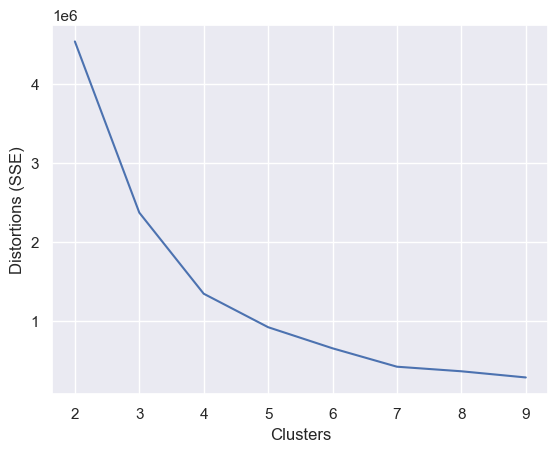

In [28]:
# Küünarnuki meetod optimaalse klastrite arvu hindamiseks. Optimaalse klastrite arvu leidmiseks saab kasutada SSE mõõtu. 
# SSE väheneb koos klastrite arvu kasvamisega, alguses tavaliselt kiiresti, hiljem aeglasemalt. Üldiselt soovime me kombineerida väikese klastrite arvu väikese SSE mõõduga. 
# Küünarnuki meetod tähendab SSE, klastrite arv graafikul nullpunktile lähima kombinatsiooni (küünarnuki) leidmist. Scikit-learn teegis vastab SSE mõõdule  `KMeans` objekti atribuut `inertia_`.

distortions = [] 
for i in range(2, 10):
    km.set_params(n_clusters=i)
    y_km_i = km.fit_predict(Xw)
    # plt.scatter(Xw[:, 0], Xw[:, 1], c=[colormap[c_id] for c_id in y_km_i])
    # #plt.grid()
    # plt.show()
    distortions.append(km.inertia_)

# Distortion ehk SSE, graafikul näha hästi nn küünarnukki, kus optimaalseim klastrite arv (kui müra on palju, nt kui andmete varieeruvus on suur, siis graafikul küünarnukk hästi ei eristu või on nö trepp-graafik)     
# K-keskmiste klasterdamine minimeerib k klastri punktide ja  klastri keskpunktide vaheliste kauguste (vigade)  
# ruutude summat (*sum of squared errors*):
plt.plot(range(2, 10), distortions) 
plt.xlabel("Clusters")
plt.ylabel("Distortions (SSE)")
plt.show()


For n_clusters = 2 The average silhouette_score is : 0.6568536504294317


c:\Users\Maive\miniconda3\envs\andmekaeve_suurandmetest\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


InvalidIndexError: (slice(None, None, None), 0)

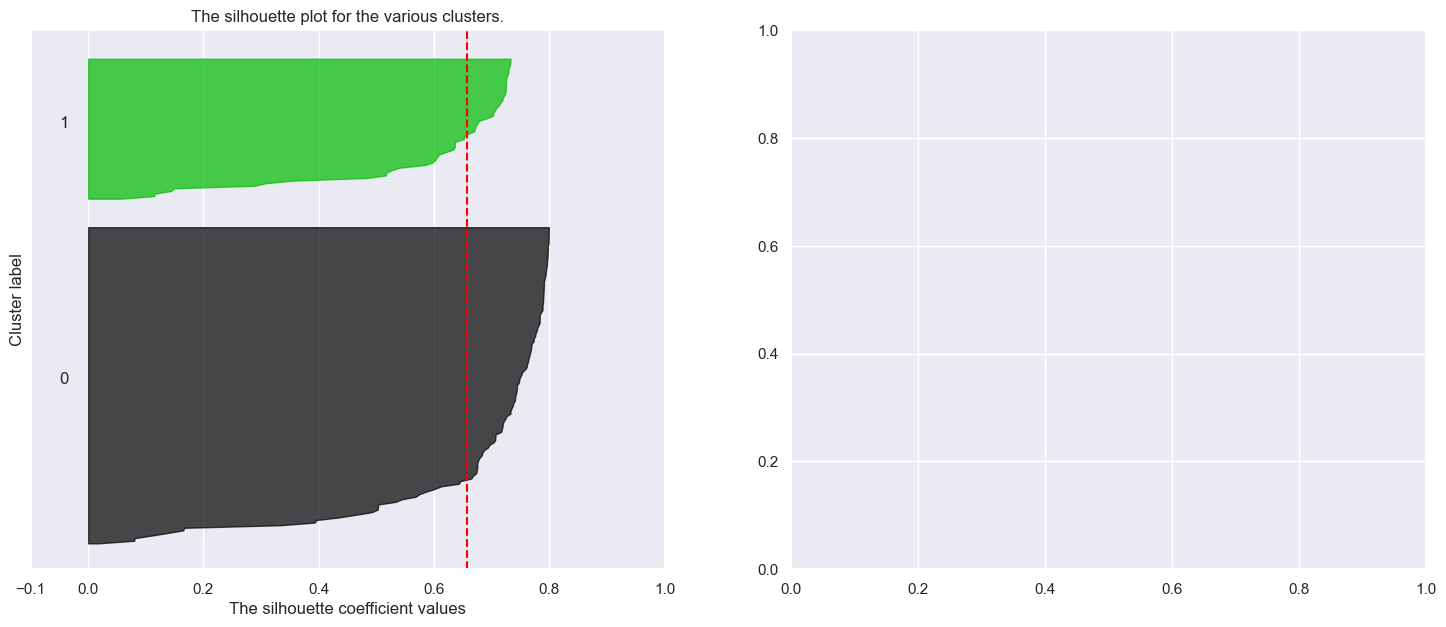

In [39]:
# Siluetimeetod optimaalse klastrite arvu hindamiseks
draw_silhouette_plots(Xw)

# Siluetidiagrammil on klastrid näidatud erinevate värvidega ja objektid, millele vastavad objekti siluetikoefitsenti horisontaaljooned, on klastri 
# sees sorditud siluetikoefitsendi järgi. Keskmist siluetikoefitsenti kujutab punane vertikaalpunktiir. Olulised asjad, mida sellel diagrammil kontrollida 
# on keskmine siluetikoefitsent (si), klastrite suurus (võiksid olla enam-vähem võrdsed), eriti madala siluetikoefitsendiga objektide (anomaaliate) arv ja jaotus klastrite vahel.
# si ehk siluetikoefitsent on vahemikus -1 ja 1, ideaaljuhul bi (objekti i keskmine kaugus jargmise klastri objektidest) >> ai (keskmine kaugus sama klastri objektidest) on 
# see 1, juhul kui $b^{(i)} = a^{(i)}$ on siluetikoefitsent 0.
